## Proyecto Final — Telecomunicaciones: identificar operadores ineficaces

Objetivo: identificar operadores con señales combinadas de ineficacia: llamadas entrantes perdidas, espera prolongada y, cuando corresponde, bajo volumen de llamadas salientes.

In [15]:
import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations
import matplotlib.pyplot as plt

calls = pd.read_csv('telecom_dataset_new.csv')
clients = pd.read_csv('telecom_clients.csv')
print('Llamadas:', calls.shape)
print('Clientes:', clients.shape)
display(calls.head())
display(clients.head())

Llamadas: (53902, 9)
Clientes: (732, 3)


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


## 1. Limpieza y análisis exploratorio

In [8]:
print('Duplicados exactos:', calls.duplicated().sum())
display(calls.isna().sum().to_frame('missing'))
display(calls['direction'].value_counts())
display(calls['internal'].value_counts(dropna=False))

Duplicados exactos: 4900


,missing
user_id,0
date,0
direction,0
internal,117
operator_id,8172
is_missed_call,0
calls_count,0
call_duration,0
total_call_duration,0


out    31917
in     21985
Name: direction, dtype: int64

False    47621
True      6164
NaN        117
Name: internal, dtype: int64

In [9]:
df=calls.drop_duplicates().copy()
df['date']=pd.to_datetime(df['date'],utc=True)
df['wait_duration']=df['total_call_duration']-df['call_duration']
df=df.merge(clients[['user_id','tariff_plan']],on='user_id',how='left')
print('Filas después de limpieza:',len(df))
display(df.describe(include='all').T)

Filas después de limpieza: 49002


,count,unique,top,freq,first,last,mean,std,min,25%,50%,75%,max
user_id,49002.0,NaN,NaN,NaN,NaT,NaT,167294.892759,598.558965,166377.0,166782.0,167158.0,167819.0,168606.0
date,49002,119,2019-11-24 21:00:00+00:00,1109,2019-08-01 21:00:00+00:00,2019-11-27 21:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
direction,49002,2,out,28999,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internal,48892,2,False,43239,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
operator_id,41546.0,NaN,NaN,NaN,NaT,NaT,916523.315409,21230.041008,879896.0,900790.5,913938.0,937708.0,973286.0
is_missed_call,49002,2,False,27549,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
calls_count,49002.0,NaN,NaN,NaN,NaT,NaT,16.462777,63.604098,1.0,1.0,4.0,12.0,4817.0
call_duration,49002.0,NaN,NaN,NaN,NaT,NaT,866.282091,3775.503352,0.0,0.0,37.0,570.0,144395.0
total_call_duration,49002.0,NaN,NaN,NaN,NaT,NaT,1156.558202,4451.473661,0.0,46.0,208.0,901.0,166155.0
wait_duration,49002.0,NaN,NaN,NaN,NaT,NaT,290.276111,1132.155291,0.0,17.0,55.0,200.0,46474.0


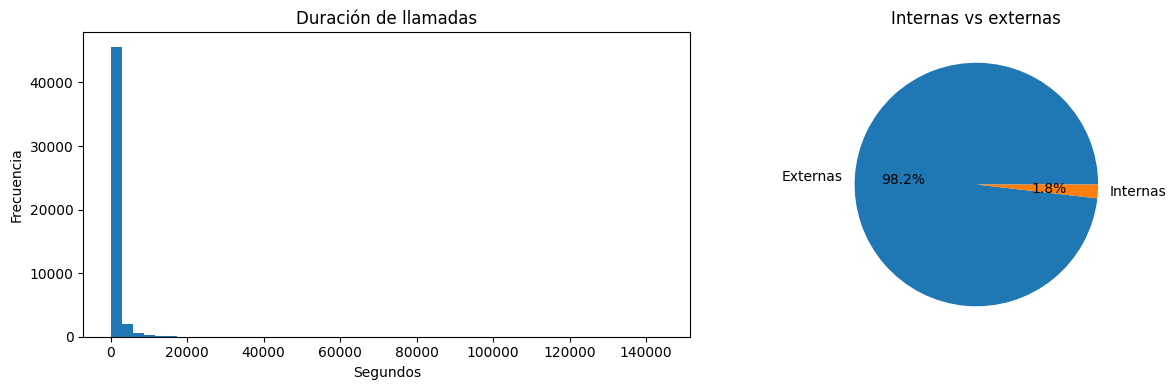

In [10]:
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].hist(df['call_duration'],bins=50)
axes[0].set_title('Duración de llamadas'); axes[0].set_xlabel('Segundos'); axes[0].set_ylabel('Frecuencia')
share=df.groupby('internal')['calls_count'].sum().rename({True:'Internas',False:'Externas'})
axes[1].pie(share,labels=share.index,autopct='%1.1f%%'); axes[1].set_title('Internas vs externas')
plt.tight_layout(); plt.show()

## 2. Identificación de operadores ineficaces

Se usan tres señales: Q3 de llamadas entrantes perdidas, Q3 de espera media por llamada entrante y Q1 de llamadas salientes. Un operador se marca como ineficaz cuando cumple al menos 2 de las 3 señales.

In [11]:
op=df[df.operator_id.notna()].copy()
op['operator_id']=op.operator_id.astype(int)
rows=[]
for oid,g in op.groupby('operator_id'):
    inc=g[g.direction=='in']; out=g[g.direction=='out']; n=inc.calls_count.sum()
    missed=inc.loc[inc.is_missed_call,'calls_count'].sum()
    rows.append([oid,int(g.user_id.iloc[0]),g.tariff_plan.iloc[0],n,missed,missed/n if n else np.nan,
                 inc.wait_duration.sum()/n if n else np.nan,out.calls_count.sum(),g.calls_count.sum()])
opstats=pd.DataFrame(rows,columns=['operator_id','user_id','tariff_plan','incoming_calls','missed_incoming_calls',
                                   'missed_incoming_rate','avg_wait_seconds','outgoing_calls','total_calls'])
inc=opstats[opstats.incoming_calls>0]; out=opstats[opstats.outgoing_calls>0]
q_missed=inc.missed_incoming_calls.quantile(.75); q_wait=inc.avg_wait_seconds.quantile(.75); q_out=out.outgoing_calls.quantile(.25)
opstats['high_missed']=opstats.missed_incoming_calls>=q_missed
opstats['high_wait']=opstats.avg_wait_seconds>=q_wait
opstats['low_outgoing']=opstats.outgoing_calls<=q_out
opstats['inefficiency_criteria']=opstats[['high_missed','high_wait','low_outgoing']].sum(axis=1)
opstats['ineffective']=opstats.inefficiency_criteria>=2
print('Umbrales:',q_missed,q_wait,q_out)
print('Operadores ineficaces:',int(opstats.ineffective.sum()))
display(opstats[opstats.ineffective].sort_values(['inefficiency_criteria','missed_incoming_calls','avg_wait_seconds'],ascending=False).head(20))

Umbrales: 1.0 21.83888888888889 11.0
Operadores ineficaces: 188


,operator_id,user_id,tariff_plan,incoming_calls,missed_incoming_calls,missed_incoming_rate,avg_wait_seconds,outgoing_calls,total_calls,high_missed,high_wait,low_outgoing,inefficiency_criteria,ineffective
465,919554,167264,B,1182,11,0.009306,32.351946,11,1193,True,True,True,3,True
246,905300,167162,C,25,6,0.240000,22.080000,0,25,True,True,True,3,True
675,937368,167580,B,22,4,0.181818,24.136364,10,32,True,True,True,3,True
349,911102,167059,C,27,3,0.111111,30.444444,0,27,True,True,True,3,True
354,911142,167059,C,20,2,0.100000,46.150000,0,20,True,True,True,3,True
643,934098,168004,C,6,2,0.333333,26.500000,0,6,True,True,True,3,True
353,911140,167059,C,70,2,0.028571,26.285714,0,70,True,True,True,3,True
145,896538,166879,A,14,1,0.071429,47.500000,0,14,True,True,True,3,True
361,912684,167272,C,27,1,0.037037,35.481481,0,27,True,True,True,3,True
323,909134,166983,C,197,1,0.005076,35.223350,5,202,True,True,True,3,True


In [12]:
display(opstats.sort_values('missed_incoming_calls',ascending=False).head(15)[
['operator_id','tariff_plan','incoming_calls','missed_incoming_calls','missed_incoming_rate','avg_wait_seconds','outgoing_calls','ineffective']])
display(opstats.sort_values('avg_wait_seconds',ascending=False).head(15)[
['operator_id','tariff_plan','incoming_calls','missed_incoming_calls','avg_wait_seconds','outgoing_calls','ineffective']])

,operator_id,tariff_plan,incoming_calls,missed_incoming_calls,missed_incoming_rate,avg_wait_seconds,outgoing_calls,ineffective
369,913942,B,2467,52,0.021078,11.987434,440,False
779,940588,A,2127,30,0.014104,3.110484,67,False
823,944226,B,180,30,0.166667,42.661111,109,True
29,885890,A,1244,26,0.020900,9.088424,58977,False
722,937956,A,773,24,0.031048,1.331177,1,True
819,944216,B,235,24,0.102128,35.608511,133,True
936,951508,A,336,21,0.062500,18.946429,146,False
28,885876,A,992,20,0.020161,9.089718,58437,False
821,944220,B,265,18,0.067925,36.067925,221,True
822,944222,B,185,17,0.091892,33.875676,344,True


,operator_id,tariff_plan,incoming_calls,missed_incoming_calls,avg_wait_seconds,outgoing_calls,ineffective
261,905842,B,2,0,115.500000,1031,False
407,917680,A,2,0,100.000000,43,False
1024,960296,B,2,0,63.000000,170,False
489,920930,A,1,0,62.000000,0,True
288,907174,B,9,0,61.888889,2524,False
506,922114,A,1,0,61.000000,11,True
168,899900,B,2,0,58.000000,0,True
316,908300,C,3,0,56.333333,0,True
348,910958,A,13,0,54.538462,0,True
674,937366,B,3,0,53.666667,2,True


## 3. Hipótesis estadísticas

**H1:** la distribución de la espera media de llamadas entrantes difiere entre A, B y C.

**H2:** la distribución del número de llamadas entrantes perdidas difiere entre A, B y C.

Se usa Kruskal–Wallis por el fuerte sesgo y la presencia de muchos ceros. Para localizar diferencias se aplican pruebas Mann–Whitney por pares con corrección de Bonferroni.

In [13]:
x=opstats[opstats.incoming_calls>0]
kw_wait=stats.kruskal(*(g.avg_wait_seconds.dropna().values for _,g in x.groupby('tariff_plan')))
kw_missed=stats.kruskal(*(g.missed_incoming_calls.dropna().values for _,g in x.groupby('tariff_plan')))
print('Kruskal-Wallis espera:',kw_wait)
print('Kruskal-Wallis perdidas:',kw_missed)
display(x.groupby('tariff_plan')[['avg_wait_seconds','missed_incoming_calls','missed_incoming_rate']].agg(['count','mean','median']))

Kruskal-Wallis espera: KruskalResult(statistic=7.086287591709588, pvalue=0.028922258330570307)
Kruskal-Wallis perdidas: KruskalResult(statistic=10.245157674352985, pvalue=0.005960631559400837)


avg_wait_seconds                       missed_incoming_calls  \
                       count       mean     median                 count   
tariff_plan                                                                
A                        186  16.889544  13.250877                   186   
B                        276  18.959929  15.000000                   276   
C                        292  16.487259  14.466216                   292   

                             missed_incoming_rate                   
                 mean median                count      mean median  
tariff_plan                                                         
A            2.075269      0                  186  0.014731    0.0  
B            1.134058      0                  276  0.018867    0.0  
C            0.777397      0                  292  0.018162    0.0

In [14]:
def pairwise_mw(data,metric):
    rows=[]
    for a,b in combinations(['A','B','C'],2):
        xa=data.loc[data.tariff_plan==a,metric].dropna()
        xb=data.loc[data.tariff_plan==b,metric].dropna()
        u,p=stats.mannwhitneyu(xa,xb,alternative='two-sided')
        rows.append([a,b,len(xa),len(xb),u,p,min(3*p,1)])
    return pd.DataFrame(rows,columns=['A','B','n_A','n_B','U','p_value','p_bonferroni'])
display(pairwise_mw(x,'avg_wait_seconds'))
display(pairwise_mw(x,'missed_incoming_calls'))

,A,B,n_A,n_B,U,p_value,p_bonferroni
0,A,B,186,276,22107.0,0.011409,0.034228
1,A,C,186,292,25842.0,0.372341,1.000000
2,B,C,276,292,43965.0,0.060566,0.181698


,A,B,n_A,n_B,U,p_value,p_bonferroni
0,A,B,186,276,29233.5,0.002136,0.006409
1,A,C,186,292,30105.0,0.017699,0.053097
2,B,C,276,292,38751.0,0.324991,0.974974


## 4. Conclusiones

- Se eliminaron duplicados exactos antes del análisis.
- La clasificación de ineficacia combina llamadas perdidas, espera y volumen saliente.
- Las pruebas globales muestran diferencias estadísticamente significativas entre planes para espera media y número de llamadas entrantes perdidas con α=0.05.
- Los operadores marcados deben interpretarse como candidatos para revisión operativa, no como una evaluación individual definitiva.


## 5. Fuentes

1. Pandas `read_csv`: carga de archivos CSV.
2. Pandas `groupby`: agregación de métricas.
3. SciPy `kruskal`: comparación no paramétrica de tres grupos.
4. SciPy `mannwhitneyu`: comparación por pares.
5. SciPy `ttest_ind`: referencia para dos muestras independientes.
6. Tableau Public: publicación y compartición del dashboard.
7. Tableau Public FAQ: características de Tableau Public.
8. Tableau: publicación de libros de trabajo.
9. Proyecto de referencia sobre análisis de operadores telefónicos: métricas y enfoque metodológico.
